# Post-Event Prediction Review

Reusable notebook for reviewing prediction accuracy after a UFC event completes. Compares saved predictions against actual results with calibration and tier analysis.

**Usage:** Set `EVENT_NAME` in the cell below, then Run All.

In [ ]:
# ── PARAMETER: change this to review a different event ──
EVENT_NAME = "UFC 327"

In [2]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

from warehouse.db import get_connection
from modeling.calibrate import assess_calibration

REPO_ROOT = Path.cwd().parent
PREDICTIONS_DIR = REPO_ROOT / "models" / "predictions"
PREDICTION_LOG = REPO_ROOT / "models" / "prediction_log.csv"

print(f"Reviewing: {EVENT_NAME}")

/home/wlodzimierrr/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Reviewing: UFC Fight Night: Moicano vs. Duncan


## 1. Load Predictions and Actual Results

In [ ]:
conn = get_connection()

# Find event
with conn.cursor() as cur:
    cur.execute("""
        SELECT event_id::text, event_name, event_date
        FROM events WHERE LOWER(event_name) LIKE %s
        ORDER BY event_date DESC LIMIT 1
    """, (f"%{EVENT_NAME.lower()}%",))
    event_row = cur.fetchone()

if not event_row:
    print(f"Event not found: {EVENT_NAME}")
    HAS_DATA = False
    RETRO_COUNT = 0
else:
    event_id, event_name, event_date = str(event_row[0]), event_row[1], event_row[2]
    date_str = str(event_date)[:10]
    print(f"Event: {event_name} ({date_str})")

    # Try saved predictions first
    pred_path = PREDICTIONS_DIR / date_str / "predictions.csv"
    saved_preds = pd.read_csv(pred_path) if pred_path.exists() else pd.DataFrame()
    saved_ids = set(saved_preds["fight_id"]) if not saved_preds.empty else set()
    if not saved_preds.empty:
        print(f"Loaded {len(saved_preds)} saved prediction(s)")

    # Count completed fights for this event
    with conn.cursor() as cur:
        cur.execute("""
            SELECT COUNT(*) FROM fights
            WHERE event_id = %s AND result_type = 'win'
        """, (event_id,))
        n_completed = cur.fetchone()[0]

    # Retroactively score fights missing from saved predictions
    retro_preds = pd.DataFrame()
    if len(saved_preds) < n_completed and n_completed > 0:
        print(f"Saved predictions cover {len(saved_preds)}/{n_completed} completed fights — scoring remaining retroactively")

        from modeling.artifacts import load_model
        from modeling.calibrate import calibrate_platt
        from modeling.data import load_bout_data
        from modeling.uncertainty import confidence_tier, flag_uncertain
        from features.debut_prior import compute_debut_priors, apply_debut_features

        prod_path = REPO_ROOT / "models" / "production_model.json"
        with open(prod_path) as f:
            prod = json.load(f)
        model, metadata = load_model(prod["artifact_path"])
        feature_cols = metadata["feature_cols"]
        db_feature_cols = [c for c in feature_cols if not c.startswith("debut_")]
        cols_sql = ", ".join(f"bf.{c}" for c in db_feature_cols)

        with conn.cursor() as cur:
            cur.execute(f"""
                SELECT bf.fight_id::text, bf.fighter_1_id::text, bf.fighter_2_id::text,
                       bf.event_date, bf.weight_class, bf.label, {cols_sql}
                FROM bout_features bf
                JOIN fights f ON bf.fight_id = f.fight_id
                WHERE f.event_id = %s
            """, (event_id,))
            rows = cur.fetchall()
            col_names = [desc[0] for desc in cur.description]

        if rows:
            rdf = pd.DataFrame(rows, columns=col_names)
            for c in feature_cols:
                if c in rdf.columns:
                    rdf[c] = pd.to_numeric(rdf[c], errors="coerce")
            for c in ["is_title_fight", "is_orthodox_vs_southpaw", "both_debuting",
                       "f1_is_southpaw", "f2_is_southpaw"]:
                if c in rdf.columns:
                    rdf[c] = rdf[c].astype(int)

            if metadata.get("debut_priors_applied"):
                val_date = metadata.get("val_date")
                all_bout = load_bout_data(conn, feature_cols=db_feature_cols)
                train_p = all_bout[all_bout["event_date"] < val_date] if val_date else all_bout
                priors = compute_debut_priors(train_p)
                rdf = apply_debut_features(rdf, priors)

            for c in feature_cols:
                if c not in rdf.columns:
                    rdf[c] = np.nan

            X = rdf[feature_cols].values
            y_prob_raw = model.predict_proba(X)[:, 1]

            # Platt calibration
            val_date = metadata.get("val_date")
            test_date = metadata.get("test_date")
            if val_date and test_date:
                all_bout = load_bout_data(conn, feature_cols=db_feature_cols)
                if metadata.get("debut_priors_applied"):
                    train_p = all_bout[all_bout["event_date"] < val_date]
                    p = compute_debut_priors(train_p)
                    all_bout = apply_debut_features(all_bout, p)
                val = all_bout[(all_bout["event_date"] >= val_date) & (all_bout["event_date"] < test_date)]
                val = val.dropna(subset=["label"])
                if len(val) > 0:
                    y_prob_val = model.predict_proba(val[feature_cols].values)[:, 1]
                    y_prob_cal = calibrate_platt(y_prob_val, val["label"].values, y_prob_raw)
                else:
                    y_prob_cal = y_prob_raw
            else:
                y_prob_cal = y_prob_raw

            # Fighter names
            all_ids = set(rdf["fighter_1_id"].tolist() + rdf["fighter_2_id"].tolist())
            with conn.cursor() as cur:
                cur.execute("SELECT fighter_id::text, full_name FROM fighters")
                name_map = {str(r[0]): r[1] for r in cur.fetchall() if str(r[0]) in all_ids}

            retro_preds = pd.DataFrame({
                "fight_id": rdf["fight_id"],
                "event_date": rdf.get("event_date"),
                "fighter_1_id": rdf["fighter_1_id"],
                "fighter_2_id": rdf["fighter_2_id"],
                "fighter_1_name": [name_map.get(fid, "Unknown") for fid in rdf["fighter_1_id"]],
                "fighter_2_name": [name_map.get(fid, "Unknown") for fid in rdf["fighter_2_id"]],
                "weight_class": rdf.get("weight_class"),
                "calibrated_prob_f1": y_prob_cal,
                "confidence_tier": confidence_tier(y_prob_cal),
                "model_name": prod["selected_model"],
                "retroactive": True,
            })
            # Exclude fights already in saved predictions
            retro_preds = retro_preds[~retro_preds["fight_id"].isin(saved_ids)]
            print(f"Scored {len(retro_preds)} fight(s) retroactively")

    # Merge saved + retroactive predictions
    if not saved_preds.empty:
        saved_preds["retroactive"] = False
    parts = [p for p in [saved_preds, retro_preds] if not p.empty]
    preds = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

    if preds.empty:
        print("No predictions (saved or retroactive) for this event.")
        HAS_DATA = False
        RETRO_COUNT = 0
    else:
        RETRO_COUNT = int(preds["retroactive"].sum()) if "retroactive" in preds.columns else 0

        # Load actual results
        fight_ids = preds["fight_id"].tolist()
        with conn.cursor() as cur:
            cur.execute("""
                SELECT fight_id::text, fighter_1_id::text, fighter_2_id::text,
                       winner_fighter_id::text, result_type
                FROM fights WHERE fight_id::text = ANY(%s)
            """, (fight_ids,))
            actual_rows = cur.fetchall()

        actuals = {}
        for r in actual_rows:
            fid = str(r[0])
            winner = str(r[3]) if r[3] else None
            if r[4] == "win" and winner == str(r[1]):
                actuals[fid] = 1
            elif r[4] == "win" and winner == str(r[2]):
                actuals[fid] = 0
            else:
                actuals[fid] = None

        preds["actual_label"] = preds["fight_id"].map(actuals)
        preds["predicted_winner"] = (preds["calibrated_prob_f1"] >= 0.5).astype(int)
        preds["correct"] = preds["predicted_winner"] == preds["actual_label"]

        resolved = preds.dropna(subset=["actual_label"]).copy()
        resolved["actual_label"] = resolved["actual_label"].astype(int)

        if len(resolved) == 0:
            print("No resolved fights — event may not be completed yet.")
            HAS_DATA = False
        else:
            HAS_DATA = True
            retro_note = f" ({RETRO_COUNT} retroactive)" if RETRO_COUNT else ""
            print(f"Resolved: {len(resolved)} / {len(preds)} fights{retro_note}")

conn.close()

## 2. Per-Fight Comparison

In [4]:
if HAS_DATA:
    display_cols = ["fighter_1_name", "fighter_2_name", "calibrated_prob_f1",
                    "confidence_tier", "actual_label", "correct"]
    review = resolved[display_cols].copy()
    review.columns = ["Fighter 1", "Fighter 2", "P(F1 wins)", "Tier", "Actual (1=F1)", "Correct"]
    review["P(F1 wins)"] = review["P(F1 wins)"].map("{:.1%}".format)
    review["Correct"] = review["Correct"].map({True: "Yes", False: "No"})
    print(review.to_string(index=False))
else:
    print("No data to display.")

             Fighter 1        Fighter 2 P(F1 wins)    Tier  Actual (1=F1) Correct
         Azamat Bekoev     Tresean Gore      65.7%  medium              0      No
         Alice Pereira     Hailey Cowan      76.0%    high              1     Yes
         Lando Vannata  Darrius Flowers      44.8% toss-up              0     Yes
      Alessandro Costa   Stewart Nicoll      61.8%  medium              1     Yes
           Jose Delano   Robert Ruchala      58.4% toss-up              1     Yes
         Guilherme Pat  Thomas Petersen      67.5%  medium              0      No
        Tommy McMillen  Manolo Zecchini      64.0%  medium              1     Yes
           Ethyn Ewing   Rafael Estevam      52.6% toss-up              1     Yes
Abdul Rakhman Yakhyaev Brendson Ribeiro      74.0%    high              1     Yes
       Virna Jandiroba    Tabatha Ricci      53.2% toss-up              1     Yes
        Renato Moicano     Chris Duncan      37.6%  medium              1      No


## 3. Accuracy Summary

In [ ]:
if HAS_DATA:
    y_true = resolved["actual_label"].values
    y_prob = resolved["calibrated_prob_f1"].values
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    ll = log_loss(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)

    retro_note = f"  ({RETRO_COUNT} scored retroactively)" if RETRO_COUNT else ""
    print(f"Overall Metrics ({len(resolved)} fights){retro_note}")
    print(f"  Accuracy:    {acc:.1%}  ({int(resolved['correct'].sum())}/{len(resolved)})")
    print(f"  Log Loss:    {ll:.4f}")
    print(f"  Brier Score: {brier:.4f}")

    # By confidence tier
    print(f"\nAccuracy by Confidence Tier:")
    for tier in ["high", "medium", "toss-up"]:
        mask = resolved["confidence_tier"] == tier
        if mask.sum() > 0:
            tier_acc = resolved.loc[mask, "correct"].mean()
            print(f"  {tier:<10s}  {tier_acc:.1%}  ({mask.sum()} fights)")

    # By weight class (if available)
    if "weight_class" in resolved.columns:
        wc_groups = resolved.groupby("weight_class")["correct"].agg(["mean", "count"])
        wc_groups = wc_groups[wc_groups["count"] >= 2].sort_values("mean", ascending=False)
        if len(wc_groups) > 1:
            print(f"\nAccuracy by Weight Class (min 2 fights):")
            for wc, row in wc_groups.iterrows():
                print(f"  {wc:<25s}  {row['mean']:.1%}  ({int(row['count'])} fights)")
else:
    print("No data.")

## 4. Calibration Plot — This Event vs Historical

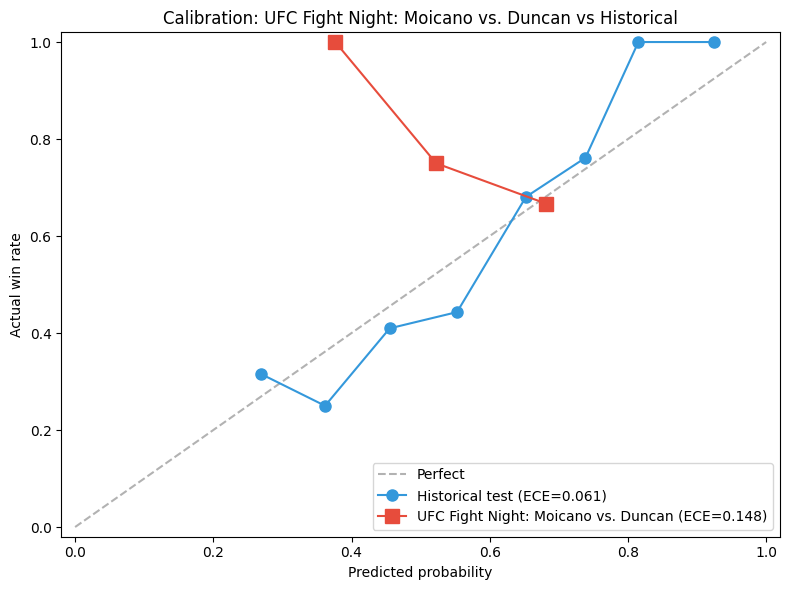

In [6]:
if HAS_DATA:
    from modeling.artifacts import load_model
    from modeling.data import load_bout_data
    from features.debut_prior import compute_debut_priors, apply_debut_features
    from modeling.calibrate import calibrate_platt

    # Load historical test set for context
    prod_path = REPO_ROOT / "models" / "production_model.json"
    with open(prod_path) as f:
        prod = json.load(f)
    model, metadata = load_model(prod["artifact_path"])
    feature_cols = metadata["feature_cols"]
    val_date = metadata.get("val_date", "2022-03-12")
    test_date = metadata.get("test_date", "2024-03-09")

    conn = get_connection()
    try:
        df = load_bout_data(conn, feature_cols=feature_cols)
        train = df[df["event_date"] < val_date]
        priors = compute_debut_priors(train)
        df = apply_debut_features(df, priors)
        test = df[df["event_date"] >= test_date].dropna(subset=["label"])
        val = df[(df["event_date"] >= val_date) & (df["event_date"] < test_date)].dropna(subset=["label"])

        y_prob_val = model.predict_proba(val[feature_cols].values)[:, 1]
        y_prob_test = model.predict_proba(test[feature_cols].values)[:, 1]
        y_prob_test_cal = calibrate_platt(y_prob_val, val["label"].values, y_prob_test)
        y_test = test["label"].values
    finally:
        conn.close()

    # Historical calibration
    cal_hist = assess_calibration(y_test, y_prob_test_cal)
    preds_h = [b["mean_predicted"] for b in cal_hist["bins"] if b["count"] > 0]
    actuals_h = [b["mean_actual"] for b in cal_hist["bins"] if b["count"] > 0]

    # This event calibration (if enough fights)
    cal_event = assess_calibration(y_true, y_prob, n_bins=5)
    preds_e = [b["mean_predicted"] for b in cal_event["bins"] if b["count"] > 0]
    actuals_e = [b["mean_actual"] for b in cal_event["bins"] if b["count"] > 0]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfect")
    ax.plot(preds_h, actuals_h, "o-", color="#3498db", markersize=8,
            label=f"Historical test (ECE={cal_hist['ece']:.3f})")
    if len(preds_e) >= 2:
        ax.plot(preds_e, actuals_e, "s-", color="#e74c3c", markersize=10,
                label=f"{event_name} (ECE={cal_event['ece']:.3f})")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Actual win rate")
    ax.set_title(f"Calibration: {event_name} vs Historical")
    ax.legend()
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No data — skipping calibration plot.")

## 5. Surprise Analysis — Biggest Upsets

In [7]:
if HAS_DATA:
    # Surprise = high-confidence wrong predictions
    wrong = resolved[~resolved["correct"]].copy()
    wrong["surprise_score"] = abs(wrong["calibrated_prob_f1"] - 0.5)
    wrong = wrong.sort_values("surprise_score", ascending=False)

    if len(wrong) == 0:
        print("No wrong predictions — perfect card!")
    else:
        print(f"Wrong predictions: {len(wrong)} / {len(resolved)}")
        print(f"\nBiggest surprises (high confidence, wrong):")
        for _, row in wrong.head(5).iterrows():
            prob = row["calibrated_prob_f1"]
            actual = "F1 won" if row["actual_label"] == 1 else "F2 won"
            print(f"  {row['fighter_1_name']} vs {row['fighter_2_name']}  "
                  f"P(F1)={prob:.1%} [{row['confidence_tier']}]  Actual: {actual}")

    # Correct high-confidence picks
    correct_high = resolved[(resolved["correct"]) & (resolved["confidence_tier"] == "high")]
    if len(correct_high) > 0:
        print(f"\nCorrect high-confidence picks: {len(correct_high)}")
        for _, row in correct_high.iterrows():
            prob = row["calibrated_prob_f1"]
            print(f"  {row['fighter_1_name']} vs {row['fighter_2_name']}  P(F1)={prob:.1%}")
else:
    print("No data.")

Wrong predictions: 3 / 11

Biggest surprises (high confidence, wrong):
  Guilherme Pat vs Thomas Petersen  P(F1)=67.5% [medium]  Actual: F2 won
  Azamat Bekoev vs Tresean Gore  P(F1)=65.7% [medium]  Actual: F2 won
  Renato Moicano vs Chris Duncan  P(F1)=37.6% [medium]  Actual: F1 won

Correct high-confidence picks: 2
  Alice Pereira vs Hailey Cowan  P(F1)=76.0%
  Abdul Rakhman Yakhyaev vs Brendson Ribeiro  P(F1)=74.0%


## 6. Rolling Accuracy Trend

Shows cumulative prediction accuracy across all reviewed events (requires `models/prediction_log.csv` with >= 3 entries).

In [8]:
if PREDICTION_LOG.exists():
    log = pd.read_csv(PREDICTION_LOG)
    if len(log) >= 3:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # Accuracy trend
        axes[0].plot(range(len(log)), log["accuracy"].astype(float), "o-", color="#2ecc71")
        axes[0].axhline(y=log["accuracy"].astype(float).mean(), color="gray", linestyle="--", alpha=0.5)
        axes[0].set_xlabel("Event #")
        axes[0].set_ylabel("Accuracy")
        axes[0].set_title("Accuracy Trend")
        axes[0].set_ylim(0, 1)

        # Log loss trend
        axes[1].plot(range(len(log)), log["log_loss"].astype(float), "o-", color="#e74c3c")
        axes[1].axhline(y=log["log_loss"].astype(float).mean(), color="gray", linestyle="--", alpha=0.5)
        axes[1].set_xlabel("Event #")
        axes[1].set_ylabel("Log Loss")
        axes[1].set_title("Log Loss Trend")

        # Brier score trend
        axes[2].plot(range(len(log)), log["brier_score"].astype(float), "o-", color="#3498db")
        axes[2].axhline(y=log["brier_score"].astype(float).mean(), color="gray", linestyle="--", alpha=0.5)
        axes[2].set_xlabel("Event #")
        axes[2].set_ylabel("Brier Score")
        axes[2].set_title("Brier Score Trend")

        plt.tight_layout()
        plt.show()

        print(f"\nPrediction log: {len(log)} events")
        print(f"  Cumulative accuracy:  {log['accuracy'].astype(float).mean():.1%}")
        print(f"  Cumulative log loss:  {log['log_loss'].astype(float).mean():.4f}")
        print(f"  Cumulative brier:     {log['brier_score'].astype(float).mean():.4f}")
        print()
        print(log.to_string(index=False))
    else:
        print(f"Only {len(log)} event(s) in prediction log — need >= 3 for trend plots.")
        print(log.to_string(index=False))
else:
    print("No prediction log found. Run `make review_event EVENT=...` to start tracking.")

No prediction log found. Run `make review_event EVENT=...` to start tracking.
